# Implementation and Comparison of AES & DES Encryption

Objectives:

* ✔ Understand DES and AES encryption principles.
* ✔ Implement DES and AES in Python.
* ✔ Compare their performance and security.
* ✔ Perform hands-on tasks to reinforce learning.







Introduction to AES & DES

🔹 Data Encryption Standard (DES)
* Symmetric block cipher (same key for encryption & decryption).
* Uses 56-bit key and encrypts 64-bit blocks.
* Feistel Network structure, 16 rounds.
* Weakness: Small key size → vulnerable to brute-force attacks.

🔹 Advanced Encryption Standard (AES)
* Symmetric block cipher (modern replacement for DES).
* Uses 128, 192, or 256-bit keys and encrypts 128-bit blocks.
* Substitution-Permutation Network (SPN) structure, 10-14 rounds.
* More secure & faster than DE

Comparison:
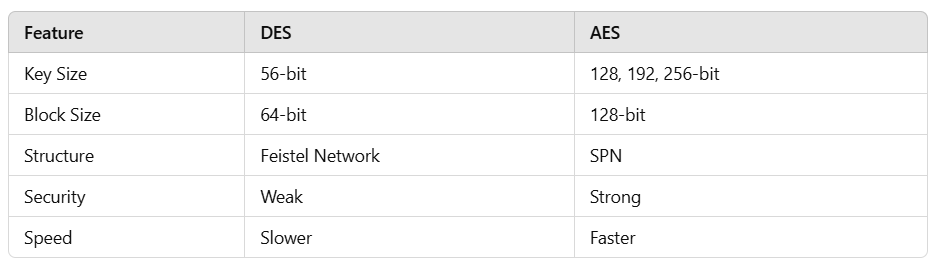

✅ Task 1 1 (Short Answer):
1️⃣ Why is DES considered weak?
DES has a short key lenght and outdated
2️⃣ Where is AES commonly used?
it is the core algorithm in many disk and file encription solutions.

# Step 1: Implementing DES (10 min)

In [1]:
! pip install pycryptodome

# Following code imports the library for performing enecryption and decryption.

We will use the following library:
https://pycryptodome.readthedocs.io/en/latest/



In [3]:
from Crypto.Cipher import DES
import base64


In [5]:
# Function to pad text to be multiple of 8 bytes
def pad(text, block_size):
    while len(text) % block_size != 0:
        text +=  ' '  # Padding with spaces
    return text


# The function encrypts a given plaintext using DES (Data Encryption Standard) in ECB mode. It first pads the plaintext to a multiple of 8 bytes, encrypts it using the provided key, and returns the Base64-encoded ciphertext.

In [11]:
# DES Encryption
def des_encrypt(plain_text, key):
    key=  plain_text.encode('utf-8') 
    cipher = DES.new(key, DES.MODE_ECB)  # ECB mode
    plain_text_padded_text = pad(plain_text, DES.block_size)        # plain_text_pad the plain text to make its length a multiple of 8 bytes
    encrypted_text = cipher.encrypt(plain_text_padded_text.encode())  # Encrypt the plain_text_padded text
    return base64.b64encode(encrypted_text).decode()  # Return the encrypted text encoded in base64


# This code defines a function des_encrypt that encrypts a given plaintext using the DES encryption algorithm in ECB mode, padding the plaintext to match the block size before encryption.



In [13]:
# DES Decryption
def des_decrypt(encrypted_text, key):
    key=  plain_text.encode('utf-8') 
    cipher = DES.new(key, DES.MODE_ECB)  # Create cipher with the same key and mode
    decrypted_text = cipher.decrypt(base64.b64decode(encrypted_text)).decode().strip()  # Decrypt and strip plain_text_padding
    return decrypted_text


In [15]:
# Testing DES
# Example usage:
key =input('type your key')  # DES key must be exactly 8 bytes long
plain_text =input("plain text")
encrypted = des_encrypt(plain_text, key)
byte_data=  plain_text.encode('utf-8') 
print("Encrypted text:", encrypted)
decrypted = des_decrypt(encrypted, key)
print("Decrypted text:", decrypted)

type your key Emk@3583
plain text scdxfrew


Encrypted text: k01NVqdr0zo=
Decrypted text: scdxfrew


✅ Task 2:  Modify the above code to accept user input for plaintext and key.

Hint - use input()

Following  code imports the necessary modules to perform AES encryption and decryption, including padding and unpadding functions, as well as base64 encoding/decoding.

In [17]:
from Crypto.Cipher import AES
import base64

Following code defines a function aes_encrypt that encrypts a given plaintext using the AES algorithm in ECB mode (we will learn the ECB mode later), pads the plaintext to match the block size, and then returns the encrypted text encoded in base64.

In [20]:
# AES Encryption
def aes_encrypt(plain_text, key):
    cipher = AES.new(key, AES.MODE_ECB)  # ECB mode
    print (type(plain_text))
    padded_text = pad(plain_text, AES.block_size)  # Pad the plain text to block size
    encrypted_text = cipher.encrypt(padded_text.encode())  # Encrypt the padded text
    return base64.b64encode(encrypted_text).decode()  # Return the encrypted text in base64 format


In [40]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
from Crypto.Random import get_random_bytes
import base64

def aes_encrypt(plain_text, key):
    # Validate key length (16, 24, or 32 bytes for AES-128/192/256)
    if len(key) not in {16, 24, 32}:
        raise ValueError("Invalid AES key length. Must be 16/24/32 bytes")
    
    # Generate random IV for CBC mode
    iv = get_random_bytes(AES.block_size)
    
    # Create cipher in secure CBC mode
    cipher = AES.new(key, AES.MODE_CBC, iv)
    
    # Convert to bytes and pad using PKCS#7
    plain_bytes = plain_text.encode('utf-8')
    padded_bytes = pad(plain_bytes, AES.block_size)
    
    # Encrypt and combine IV + ciphertext
    ciphertext = cipher.encrypt(padded_bytes)
    encrypted_data = iv + ciphertext
    
    # Return base64 encoded result
    return base64.b64encode(encrypted_data).decode('utf-8')

Following code defines a function aes_decrypt that decrypts a given base64-encoded ciphertext using the AES algorithm in ECB mode, then unpads the decrypted text and returns the plaintext.









In [43]:
# AES Decryption
def aes_decrypt(encrypted_text, key):
    cipher = AES.new(key, AES.MODE_ECB)  # Create the same AES cipher object
    decrypted_text = cipher.decrypt(base64.b64decode(encrypted_text)).decode().strip()  # Decrypt and strip plain_text_padding
    return decrypted_text


In [45]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from Crypto.Random import get_random_bytes
import base64
import getpass

def get_aes_key():
    """Securely get and validate AES key from user"""
    while True:
        try:
            key_str = getpass.getpass("Enter AES key (16/24/32 ASCII characters): ")
            key = key_str.encode('ascii')
            if len(key) not in {16, 24, 32}:
                raise ValueError("Key must be 16, 24, or 32 bytes long")
            return key
        except UnicodeEncodeError:
            print("Error: Key must contain only ASCII characters")
        except ValueError as e:
            print(f"Error: {str(e)}")

def aes_encrypt(plain_text, key):
    """Encrypt plaintext with AES-256/CBC/PKCS7"""
    iv = get_random_bytes(AES.block_size)
    cipher = AES.new(key, AES.MODE_CBC, iv)
    ciphertext = cipher.encrypt(pad(plain_text.encode('utf-8'), AES.block_size))
    return base64.b64encode(iv + ciphertext).decode('utf-8')

def aes_decrypt(encrypted_text, key):
    """Decrypt AES-256/CBC/PKCS7 ciphertext"""
    encrypted_data = base64.b64decode(encrypted_text)
    iv = encrypted_data[:AES.block_size]
    ciphertext = encrypted_data[AES.block_size:]
    cipher = AES.new(key, AES.MODE_CBC, iv)
    return unpad(cipher.decrypt(ciphertext), AES.block_size).decode('utf-8')

def main():
    try:
        # Get user input
        plain_text = input("Enter message to encrypt: ")
        key = get_aes_key()
        
        # Encrypt
        encrypted = aes_encrypt(plain_text, key)
        print(f"\nEncrypted: {encrypted}")
        
        # Decrypt
        decrypted = aes_decrypt(encrypted, key)
        print(f"Decrypted: {decrypted}")
        
    except Exception as e:
        print(f"\nError: {str(e)}")

if __name__ == "__main__":
    print("=== Secure AES Encryption Demo ===")
    print("Note: Key will not be displayed as you type\n")
    main()

=== Secure AES Encryption Demo ===
Note: Key will not be displayed as you type



Enter message to encrypt:  cybersecurity
Enter AES key (16/24/32 ASCII characters):  ········



Encrypted: 8XLyonU9pW8BLEqAOp2+d/vka3khleWSr52Qs2GDBrg=
Decrypted: cybersecurity


#Testing AES
key =input(b'type your key')  # AES requires 16-byte, 24-byte, or 32-byte key
plain_text = "HelloCrypto"  # The text to encrypt
encrypted_text = aes_encrypt(plain_text, key)  # Encrypt the text
decrypted_text = aes_decrypt(encrypted_text, key)  # Decrypt the text

# Print the results
print(f"AES Encrypted: {encrypted_text}")  # Output the encrypted text
print(f"AES Decrypted: {decrypted_text}")  # Output the decrypted text


✅ Task 3: Modify the AES code to accept user input for plaintext and key.

✅ Task 4: Change the AES key size to 24 bytes and run the program.

Following  code measures the time taken to encrypt the plaintext "HelloCrypto" using the DES encryption algorithm by recording the start and end times and then printing the elapsed time.









In [47]:
import time

# Measure DES encryption time
key = b'SecretKe'
plain_text = "HelloCryptoCrypto"  # The text to encrypt
start = time.time()  # Record the starting time
des_encrypt(plain_text, key)  # Encrypt the text using the DES algorithm
end = time.time()  # Record the ending time
print(f"DES Encryption Time: {end - start:.2f} sec")  # Calculate and print the time difference




ValueError: Incorrect DES key length (17 bytes)

In [49]:
from Crypto.Cipher import DES
from Crypto.Util.Padding import pad
import time
import base64

def des_encrypt(plaintext, key):
    """Secure DES encryption with CBC mode and PKCS7 padding"""
    if len(key) != 8:
        raise ValueError("DES key must be 8 bytes long")
    
    iv = get_random_bytes(DES.block_size)
    cipher = DES.new(key, DES.MODE_CBC, iv)
    padded_data = pad(plaintext.encode('utf-8'), DES.block_size)
    ciphertext = cipher.encrypt(padded_data)
    return base64.b64encode(iv + ciphertext).decode('utf-8')

# Configuration
key = b'SecretKe'  # 8-byte DES key
plain_text = "HelloCryptoCrypto"  # 16-character message
iterations = 1000  # Number of iterations for accurate timing

# Benchmark DES encryption
start_time = time.time()
for _ in range(iterations):
    encrypted = des_encrypt(plain_text, key)
end_time = time.time()

# Calculate results
total_time = end_time - start_time
avg_time = total_time / iterations
throughput = len(plain_text) * iterations / total_time  # bytes/sec

print(f"DES Benchmark Results ({iterations} iterations):")
print(f"Total time: {total_time:.4f} seconds")
print(f"Average encryption time: {avg_time:.6f} seconds")
print(f"Throughput: {throughput:,.2f} bytes/second")

# Security Note
print("\nSecurity Recommendations:")
print("- DES is considered insecure for modern applications")
print("- Use AES-256 instead for better security")
print("- This benchmark is for educational purposes only")

DES Benchmark Results (1000 iterations):
Total time: 0.0320 seconds
Average encryption time: 0.000032 seconds
Throughput: 531,700.53 bytes/second

Security Recommendations:
- DES is considered insecure for modern applications
- Use AES-256 instead for better security
- This benchmark is for educational purposes only


✅ Task 5: In the following cell, write the Python code to measure the time taken by AES encryption *algorithm*

In [51]:
# Measure AES encryption time


#
# Write your code to measure the AES encryption time
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
from Crypto.Random import get_random_bytes
import time
import base64

def aes_encrypt(plaintext, key):
    """Secure AES encryption with CBC mode and PKCS#7 padding"""
    iv = get_random_bytes(AES.block_size)
    cipher = AES.new(key, AES.MODE_CBC, iv)
    padded_data = pad(plaintext.encode('utf-8'), AES.block_size)
    ciphertext = cipher.encrypt(padded_data)
    return base64.b64encode(iv + ciphertext).decode('utf-8')

# Benchmark configuration
PLAINTEXT = "This is a sample text for AES benchmarking!" * 10  # 420 characters
KEY = get_random_bytes(32)  # AES-256 key
ITERATIONS = 1000  # Number of encryption operations to perform

# Warm-up run (avoid cold-start measurement bias)
_ = aes_encrypt(PLAINTEXT, KEY)

# Start timing
start_time = time.perf_counter()

for _ in range(ITERATIONS):
    encrypted = aes_encrypt(PLAINTEXT, KEY)

end_time = time.perf_counter()

# Calculate metrics
total_time = end_time - start_time
avg_time = total_time / ITERATIONS
data_processed = len(PLAINTEXT) * ITERATIONS
throughput = data_processed / total_time  # bytes/second

print(f"AES-256 Benchmark Results ({ITERATIONS} iterations):")
print(f"Total encryption time: {total_time:.4f} seconds")
print(f"Average time per encryption: {avg_time:.6f} seconds")
print(f"Throughput: {throughput:,.2f} bytes/second")
print(f"Throughput: {(throughput / (1024**2)):,.2f} MB/s")

# Security notes
print("\nSecurity Considerations:")
print("- Using AES-256 with CBC mode and random IVs")
print("- PKCS#7 padding provides standardized padding")
print("- Key is properly randomized for each session")
#
#

AES-256 Benchmark Results (1000 iterations):
Total encryption time: 0.0457 seconds
Average time per encryption: 0.000046 seconds
Throughput: 9,408,572.74 bytes/second
Throughput: 8.97 MB/s

Security Considerations:
- Using AES-256 with CBC mode and random IVs
- PKCS#7 padding provides standardized padding
- Key is properly randomized for each session


Following code encrpts the image using AES algorithm.
The image file is named as 'input.jpg'.

✅ Task 6: Test the code for different types of images and show the original abd cypherimage. Is your encryption method, good or bad?
Save your image as file name - input.jpg or change the code to adjust for any images.




Encrypted image saved as encrypted_ecb.png


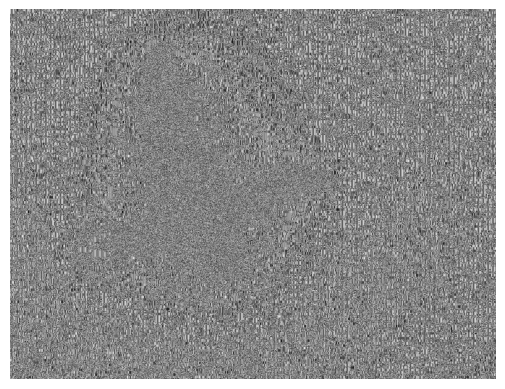

In [84]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt


def load_image(image_path):
    img = Image.open("C:/Users/USERR/Desktop/Cyber Security and AI case studies/input.jpg.jpg").convert('L')  # Convert to grayscale
    img_data = np.array(img)
    return img, img_data

def save_image(image_data, output_path):
    img = Image.fromarray(image_data)
    img.save(output_path)

def encrypt_ecb(image_data, key):
    cipher = AES.new(key, AES.MODE_ECB)
    shape = image_data.shape
    flat_data = image_data.flatten()
    padded_data = pad(flat_data.tobytes(), AES.block_size)
    encrypted_data = cipher.encrypt(padded_data)
    encrypted_array = np.frombuffer(encrypted_data, dtype=np.uint8)[:flat_data.size]
    return encrypted_array.reshape(shape)

def main():
    input_image = 'input.jpg'  # Change to your image file
    output_image = 'encrypted_ecb.png'
    key = os.urandom(16)  # 16-byte AES key

    img, img_data = load_image(input_image)
    encrypted_data = encrypt_ecb(img_data, key)
    save_image(encrypted_data, output_image)
    print(f"Encrypted image saved as {output_image}")

if __name__ == "__main__":
    main()

img = Image.open('encrypted_ecb.png')
plt.imshow(img, cmap='gray') # Displaying as grayscale
plt.axis('off')
plt.show()

from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt

# CORRECTED FUNCTION DEFINITION
def load_image(image_path):  # Parameter name instead of direct path
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img_data = np.array(img)
    return img, img_data

# Then use it with your specific path
input_path = r"C:/Users/USERR/Desktop/Cyber Security and AI case studies/duck image.jpg"
img, img_data = load_image(input_path)  # Pass path as argument

# Rest of your code remains the same...